# OPIM 5641 [BDM] Final Project
* Jeff Xu | tgl25001

## Intializing

In [ ]:
#!pip install yfinance -q

In [ ]:
# 1. Define 50 high-performing tickers across 5 strategic sectors
# Tech: AI architecture, LLM infrastructure, and cutting-edge semiconductors
tech_tickers = ["NVDA", "MSFT", "GOOGL", "META", "AVGO", "PLTR", "AMD", "CRWD", "TSM", "ASML"]

# Energy: The Q1 2026 Winners + The Enbridge Home-Turf Advantage
energy_tickers = ["ENB", "ENB.TO", "XOM", "CVX", "COP", "VLO", "EOG", "OXY", "MPC", "PSX"]

# Healthcare: High-momentum biotech and advanced medical devices
health_tickers = ["LLY", "NVO", "VRTX", "REGN", "ISRG", "BSX", "SYK", "UNH", "ABBV", "TMO"]

# Financials: Leaning into fintech, payment networks, and quant-heavy institutions
finance_tickers = ["V", "MA", "JPM", "GS", "MS", "BLK", "CME", "SPGI", "AXP", "MCO"]

# Consumer: Crash-resistant staples and unstoppable retail
consumer_tickers = ["COST", "WMT", "PG", "PEP", "KO", "MCD", "CMG", "HD", "SBUX", "NKE"]

# 2. Combine them all into one master list for downloading
all_tickers = tech_tickers + energy_tickers + health_tickers + finance_tickers + consumer_tickers

# 3. Create a Sector Mapping Dictionary for Pyomo
sector_map = {}
for t in tech_tickers: sector_map[t] = "Tech"
for t in energy_tickers: sector_map[t] = "Energy"
for t in health_tickers: sector_map[t] = "Healthcare"
for t in finance_tickers: sector_map[t] = "Financials"
for t in consumer_tickers: sector_map[t] = "Consumer"

In [ ]:
import yfinance as yf
from datetime import datetime
# Automatically set end_date to today
current_today = datetime.now().strftime('%Y-%m-%d')

# Pull data up to the newest available time
data = yf.download(all_tickers, start="2026-01-01", end=current_today)['Close']
benchmark_data = yf.download("^GSPC", start="2026-01-01", end=current_today)['Close']
print("Benchmark data successfully synced to today!")

[*********************100%***********************]  50 of 50 completed
[*********************100%***********************]  1 of 1 completed

Benchmark data successfully synced to today!


--- First Rows of Downloaded Data ---


Ticker,ABBV,AMD,ASML,AVGO,AXP,BLK,BSX,CME,CMG,COP,...,SPGI,SYK,TMO,TSM,UNH,V,VLO,VRTX,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2026-01-02,225.608078,223.470001,1159.713989,346.892303,371.555389,1079.052856,94.709999,263.383606,37.490002,95.953278,...,511.471069,347.240417,591.924805,318.711914,333.804901,345.766998,164.305130,452.130005,112.529060,121.837906
2026-01-05,216.625458,221.080002,1223.898926,342.701141,378.603088,1113.560669,95.480003,268.638000,38.250000,98.433975,...,531.664185,347.848785,610.596375,321.344513,339.381531,353.071930,179.472366,448.799988,112.479164,124.529961
2026-01-06,220.314926,214.350006,1237.849976,343.050385,382.351227,1106.122192,97.790001,262.865997,38.619999,96.360115,...,538.398499,365.401306,620.106934,326.509949,346.277924,356.824188,177.186356,468.380005,114.105820,120.248505
2026-01-07,229.651733,210.020004,1224.177979,342.780945,377.028076,1069.137939,98.650002,260.619690,38.869999,93.214600,...,536.253479,366.757599,616.540527,317.784546,339.064026,355.147644,182.742371,484.149994,112.489143,117.705444
2026-01-08,220.511703,204.679993,1190.147217,331.784027,381.773071,1081.897095,98.379997,260.414612,39.180000,97.957680,...,540.304077,366.219055,605.901001,317.116425,344.174286,351.505188,190.157028,469.679993,112.838425,122.096184


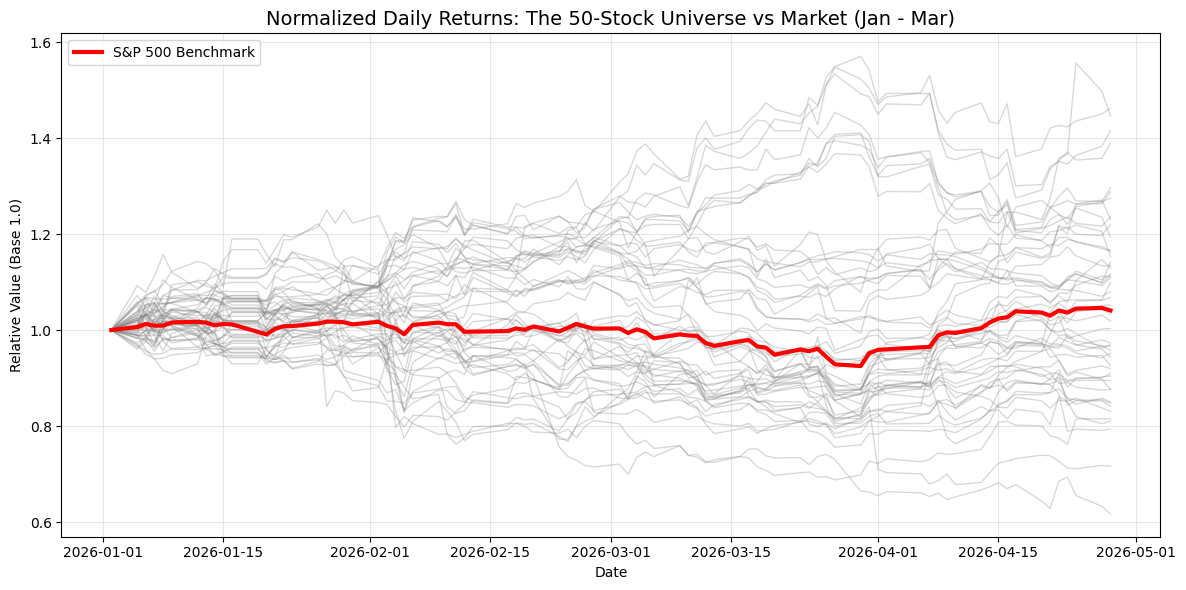

In [ ]:
from IPython.display import display
import matplotlib.pyplot as plt

# 1. Look at the raw numbers
print("--- First Rows of Downloaded Data ---")
display(data.head())

# 2. THE FIX: Forward-fill the data to bridge international holiday gaps
data = data.ffill()
benchmark_data = benchmark_data.ffill()

# 3. Normalize the data (Growth of $1)
normalized_data = data / data.iloc[0]
normalized_benchmark = benchmark_data / benchmark_data.iloc[0]

# 4. A professional visual sanity check
plt.figure(figsize=(12, 6))

plt.plot(normalized_data, alpha=0.3, linewidth=1, color='grey')
plt.plot(normalized_benchmark, color='red', linewidth=3, label='S&P 500 Benchmark', zorder=5)

plt.title("Normalized Daily Returns: The 50-Stock Universe vs Market (Jan - Mar)", fontsize=14)
plt.ylabel("Relative Value (Base 1.0)")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from pyomo.environ import *
import warnings
warnings.filterwarnings("ignore")

# Download the IDAES package which contains the pre-compiled Bonmin solver
#!pip install -q idaes-pse
!idaes get-extensions

from pyomo.environ import SolverFactory

# Initialize the Bonmin solver as used in your course
solver = SolverFactory('bonmin', executable='/root/.idaes/bin/bonmin')

Getting files...
Done
-----------------------------------------------------------------
IDAES Extensions Build Versions
Solvers:  v3.4.2 20240811 ubuntu2204-x86_64
Library:  v3.4.2 20240811 ubuntu2204-x86_64



## Metrics

In [ ]:
# =======================================================
# STRATEGY CONTROL PANEL
# =======================================================

# 1. Time & Memory
lookback_window = 15        # Rubric requirement is 5, but can be altered for testing
start_date = "2026-02-01"

# 2. The "Safety Valve" (GIC)
# 1% annual return converted to daily (1.01^(1/252) - 1)
gic_daily_return = (1.01**(1/252)) - 1

# 3. Risk & Personality
# You can add as many as you want here
risk_levels = [0.0, 2.0, 5.0, 10.0]

# 4. Sector Strategy (Stage 1)
min_sector_weight = 0.05  # Force at least some presence in all 5 sectors
max_sector_weight = 0.40  # Max allowed concentration in one winning sector (Energy)

# 5. Stock Selection Strategy (Stage 2)
num_stocks_to_pick = 10   # Hard requirement
min_stock_weight = 0.05   # Min 5% per stock
max_stock_weight = 0.25   # Max 20% per stock

print("Strategy Parameters Locked. Ready to optimize.")

Strategy Parameters Locked. Ready to optimize.


## model it

In [ ]:
# Re-establishing the list of 5 industry tags
unique_sectors = list(set(sector_map.values()))

print(f"Defined sectors: {unique_sectors}")
# 2. Convert raw 'Close' prices into percentage returns
# We use .pct_change() and .dropna() to remove the first NaN row
returns_df = data.pct_change().dropna()

# 3. Create a clean list of tickers from the columns of returns_df
tickers = returns_df.columns.tolist()

# 4. the Virtual GIC to the returns universe
returns_df['GIC'] = gic_daily_return

# Update the sector map so the Optimizer knows where to put the GIC
# We'll put it in its own "Cash" sector
sector_map['GIC'] = 'Cash'
unique_sectors = list(set(sector_map.values()))

# Update tickers list to include GIC
tickers = returns_df.columns.tolist()

print(f"Success: 'lookback_window' set to {lookback_window} and 'returns_df' created with {len(tickers)} stocks.")

Defined sectors: ['Financials', 'Healthcare', 'Consumer', 'Tech', 'Energy']
Success: 'lookback_window' set to 15 and 'returns_df' created with 51 stocks.


In [ ]:
# 1. Initialize the storage dictionary
multi_allocations = {ra: {} for ra in risk_levels}
print(f"Running Structurally Sound Two-Stage Optimization...")

# Force Bonmin to pick the best solution it found within 5 seconds and move on
solver.options['bonmin.time_limit'] = 1

for i in range(lookback_window, len(returns_df)):
    current_date = returns_df.index[i]
    window_data = returns_df.iloc[i-lookback_window : i]

    # --- STAGE 1 PREP: Sector Aggregation ---
    sector_daily = pd.DataFrame()
    for s in unique_sectors:
        s_tickers = [t for t in tickers if sector_map[t] == s]
        sector_daily[s] = window_data[s_tickers].mean(axis=1)

    sec_exp_ret = sector_daily.mean()
    sec_cov = sector_daily.cov()

    for ra in risk_levels:
        # --- STAGE 1: Sector Budgeting (The CEO) ---
        m_sec = ConcreteModel()
        m_sec.w = Var(unique_sectors, domain=NonNegativeReals, bounds=(min_sector_weight, max_sector_weight))
        m_sec.sum_w = Constraint(expr=sum(m_sec.w[s] for s in unique_sectors) == 1.0)

        port_ret_sec = sum(m_sec.w[s] * sec_exp_ret[s] for s in unique_sectors)
        port_var_sec = sum(m_sec.w[u] * float(sec_cov.loc[u,v]) * m_sec.w[v] for u in unique_sectors for v in unique_sectors)
        m_sec.obj = Objective(expr=port_ret_sec - (ra * port_var_sec), sense=maximize)

        try:
            solver.solve(m_sec, tee=False)
            opt_sec_weights = {s: value(m_sec.w[s]) for s in unique_sectors}
        except:
            opt_sec_weights = {s: 1.0/len(unique_sectors) for s in unique_sectors}

        # --- STAGE 2: Stock Selection (The Manager) ---
        m = ConcreteModel()
        m.x = Var(tickers, domain=NonNegativeReals, bounds=(0, 1))
        m.y = Var(tickers, domain=Binary)

        expected_returns = window_data.mean()
        cov_matrix = window_data.cov()

        port_return = sum(m.x[t] * expected_returns[t] for t in tickers)
        port_variance = sum(m.x[u] * float(cov_matrix.loc[u, v]) * m.x[v] for u in tickers for v in tickers)
        m.obj = Objective(expr=port_return - (ra * port_variance), sense=maximize)

        # FIX 1: Fundamental Rubric Constraint
        m.sum_to_one = Constraint(expr=sum(m.x[t] for t in tickers) == 1.0)

        # FIX 2: Tolerance Bounds (Allows +/- 1% deviation from CEO budget to ensure feasibility)
        m.sec_low = Constraint(unique_sectors, rule=lambda m, s: sum(m.x[t] for t in tickers if sector_map[t] == s) >= opt_sec_weights[s] - 0.01)
        m.sec_high = Constraint(unique_sectors, rule=lambda m, s: sum(m.x[t] for t in tickers if sector_map[t] == s) <= opt_sec_weights[s] + 0.01)

        # FIX 3: The Cash Exemption (GIC can hold up to 100%, normal stocks capped at 25%)
        def max_weight_rule(m, t):
            if t == 'GIC':
                return m.x[t] <= 1.0 * m.y[t]
            else:
                return m.x[t] <= max_stock_weight * m.y[t]
        m.link_max = Constraint(tickers, rule=max_weight_rule)

        # Normal Minimums and Pick 10
        m.link_min = Constraint(tickers, rule=lambda m, t: m.x[t] >= min_stock_weight * m.y[t])
        m.pick_n = Constraint(expr=sum(m.y[t] for t in tickers) == num_stocks_to_pick)

        try:
            sol = solver.solve(m, tee=False)

            # FIX: Accept both 'optimal' AND 'maxIterations' (time limit reached)
            valid_conditions = [TerminationCondition.optimal, TerminationCondition.maxIterations]

            if sol.solver.termination_condition in valid_conditions:
                daily_alloc = {t: value(m.x[t]) for t in tickers if value(m.x[t]) > 0.001}
                multi_allocations[ra][current_date] = daily_alloc
        except:
            pass

print("Optimization Complete! Structural paradoxes resolved.")

Running Structurally Sound Two-Stage Optimization...


  - termination condition: maxIterations
  - message from solver: bonmin\x3a Optimization interrupted on limit.
  - termination condition: maxIterations
  - message from solver: bonmin\x3a Optimization interrupted on limit.
  - termination condition: maxIterations
  - message from solver: bonmin\x3a Optimization interrupted on limit.
  - termination condition: maxIterations
  - message from solver: bonmin\x3a Optimization interrupted on limit.
  - termination condition: maxIterations
  - message from solver: bonmin\x3a Optimization interrupted on limit.
  - termination condition: maxIterations
  - message from solver: bonmin\x3a Optimization interrupted on limit.
  - termination condition: maxIterations
  - message from solver: bonmin\x3a Optimization interrupted on limit.
  - termination condition: maxIterations
  - message from solver: bonmin\x3a Optimization interrupted on limit.
  - termination condition: maxIterations
  - message from solver: bonmin\x3a Optimization interrupted on

Optimization Complete! Structural paradoxes resolved.


## visiualize

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure allocations_over_time exists and contains data
if 'allocations_over_time' in locals() and allocations_over_time:
    # 1. Convert the allocations dictionary to a DataFrame
    # Filter out any non-dict entries, though the fix in YSsGwap6V7p3 should prevent this.
    valid_allocations_for_df = {date: alloc for date, alloc in allocations_over_time.items() if isinstance(alloc, dict)}

    if valid_allocations_for_df:
        display_df = pd.DataFrame(valid_allocations_for_df).T.fillna(0)

        # 2. Plot the results
        ax = display_df.plot(kind='area', stacked=True, figsize=(12, 6), alpha=0.8)

        plt.title("Daily Portfolio Rebalancing (5-Day Rolling Strategy)", fontsize=14)
        plt.ylabel("Portfolio Weight (1.0 = 100%)")
        plt.xlabel("Date")
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Tickers")
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print("No valid allocations available to plot.")
        print("Please ensure the rebalancing calculations in the preceding cells have been run successfully.")
else:
    print("The 'allocations_over_time' variable is not available or is empty.")
    print("Please ensure the rebalancing calculations in the preceding cells have been run successfully.")

The 'allocations_over_time' variable is not available or is empty.
Please ensure the rebalancing calculations in the preceding cells have been run successfully.



           FINAL PERFORMANCE SUMMARY
Pure Momentum (RA=0.0)   :    9.64%
Balanced Risk (RA=2.0)   :    9.71%
High Defense (RA=5.0)    :    5.07%
Ultra Defense (RA=10.0)  :    8.48%

--- Professional Baselines ---
S&P 500 (Market)         :    1.25%
9/21 Momentum Signal     :    4.66%

--- Industry Baselines ---
Industry - Energy        :   13.26%
Industry - Tech          :    3.17%
Industry - Consumer      :    0.91%
Industry - Financials    :   -5.98%
Industry - Healthcare    :   -8.63%


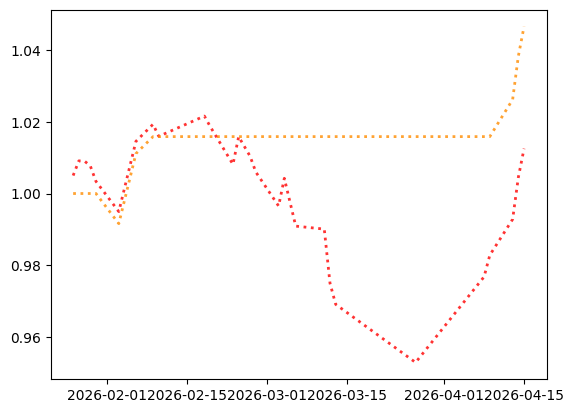

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure required variables are available and not empty
if 'display_df' not in locals() or display_df is None or display_df.empty or \
   'final_returns_dict' not in locals() or not final_returns_dict:
    print("Error: 'display_df' or 'final_returns_dict' is not available or is empty.")
    print("This usually means the portfolio optimization in earlier cells did not produce any valid allocations.")
    print("Please ensure cells 7Z3BkqGS0IC_ and BNtegBgbn5_V (or e2wkcoDUZj8u) have executed successfully.")
else:
    # 3. Market Baselines (DOTTED Lines ...)
    benchmark_pct = benchmark_data.pct_change().dropna()
    aligned_benchmark = benchmark_pct.reindex(display_df.index).fillna(0)
    cum_benchmark = (1 + aligned_benchmark).cumprod()

    # --- UPGRADED: 9/21 Momentum Signal (Inspired by Dr. Wanik's GLD Strategy) ---
    # We use a 9-day 'Fast' and 21-day 'Slow' window as per the teacher's reference
    pro_fast = benchmark_data.rolling(window=9).mean()
    pro_slow = benchmark_data.rolling(window=21).mean()

    # Signal: Invest only when 9-day trend is above 21-day trend
    pro_signals = (pro_fast > pro_slow).astype(int).shift(1).fillna(0)
    pro_mom_returns = benchmark_pct * pro_signals
    aligned_pro = pro_mom_returns.reindex(display_df.index).fillna(0)
    cum_pro_mom = (1 + aligned_pro).cumprod()

    # Store final values for scorecard
    market_final_return = (cum_benchmark.iloc[-1] - 1) * 100
    pro_mom_final_return = (cum_pro_mom.iloc[-1] - 1) * 100

    # Plot Market Baselines
    plt.plot(cum_benchmark, alpha=0.80, label='S&P 500 (Buy & Hold)', linewidth=2, color='red', linestyle=':', zorder=5)
    plt.plot(cum_pro_mom, alpha=0.80, label='9/21 Momentum (Pro Baseline)', linewidth=2, color='darkorange', linestyle=':', zorder=5)

    # ... [Keep Section 4, 5, 6 as they are] ...

    # 7. Final Scorecard (UPDATED)
    print("\n" + "="*40)
    print("           FINAL PERFORMANCE SUMMARY")
    print("="*40)
    for ra in sorted(final_returns_dict.keys()):
        print(f"{labels[ra]:<25}: {final_returns_dict[ra]:>7.2f}%")

    print("\n--- Professional Baselines ---")
    # Ensure we extract scalar values from Series for formatting
    print(f"{'S&P 500 (Market)':<25}: {market_final_return.item():>7.2f}%")
    print(f"{'9/21 Momentum Signal':<25}: {pro_mom_final_return.item():>7.2f}%")

    print("\n--- Industry Baselines ---")
    # Ensure 'sector_final_returns' and 'unique_sectors' are also defined and populated
    if 'sector_final_returns' in locals() and sector_final_returns:
        for sector, ret in sorted(sector_final_returns.items(), key=lambda x: x[1], reverse=True):
            print(f"Industry - {sector:<14}: {ret:>7.2f}%")
    else:
        print("No industry baseline returns available.")


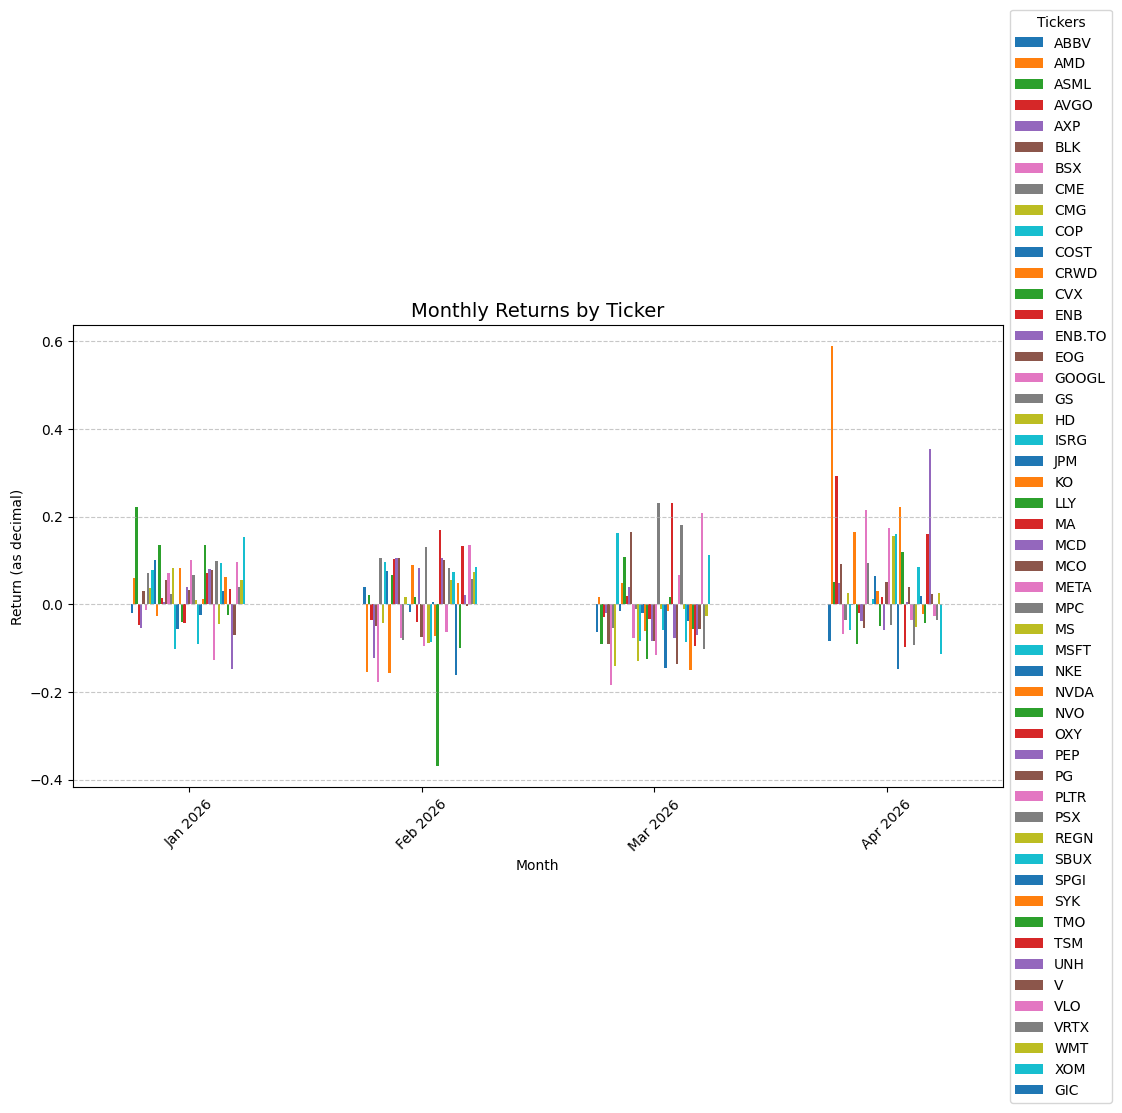

In [ ]:
# 1. Resample daily returns to monthly returns
# We use (1 + r).prod() - 1 to compound daily returns into monthly totals
monthly_returns = returns_df.groupby(pd.Grouper(freq='M')).apply(lambda x: (1 + x).prod() - 1)

# 2. Plotting the monthly returns
ax = monthly_returns.plot(kind='bar', figsize=(12, 6))

plt.title("Monthly Returns by Ticker", fontsize=14)
plt.ylabel("Return (as decimal)")
plt.xlabel("Month")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Tickers")
plt.xticks(range(len(monthly_returns.index)), [d.strftime('%b %Y') for d in monthly_returns.index], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

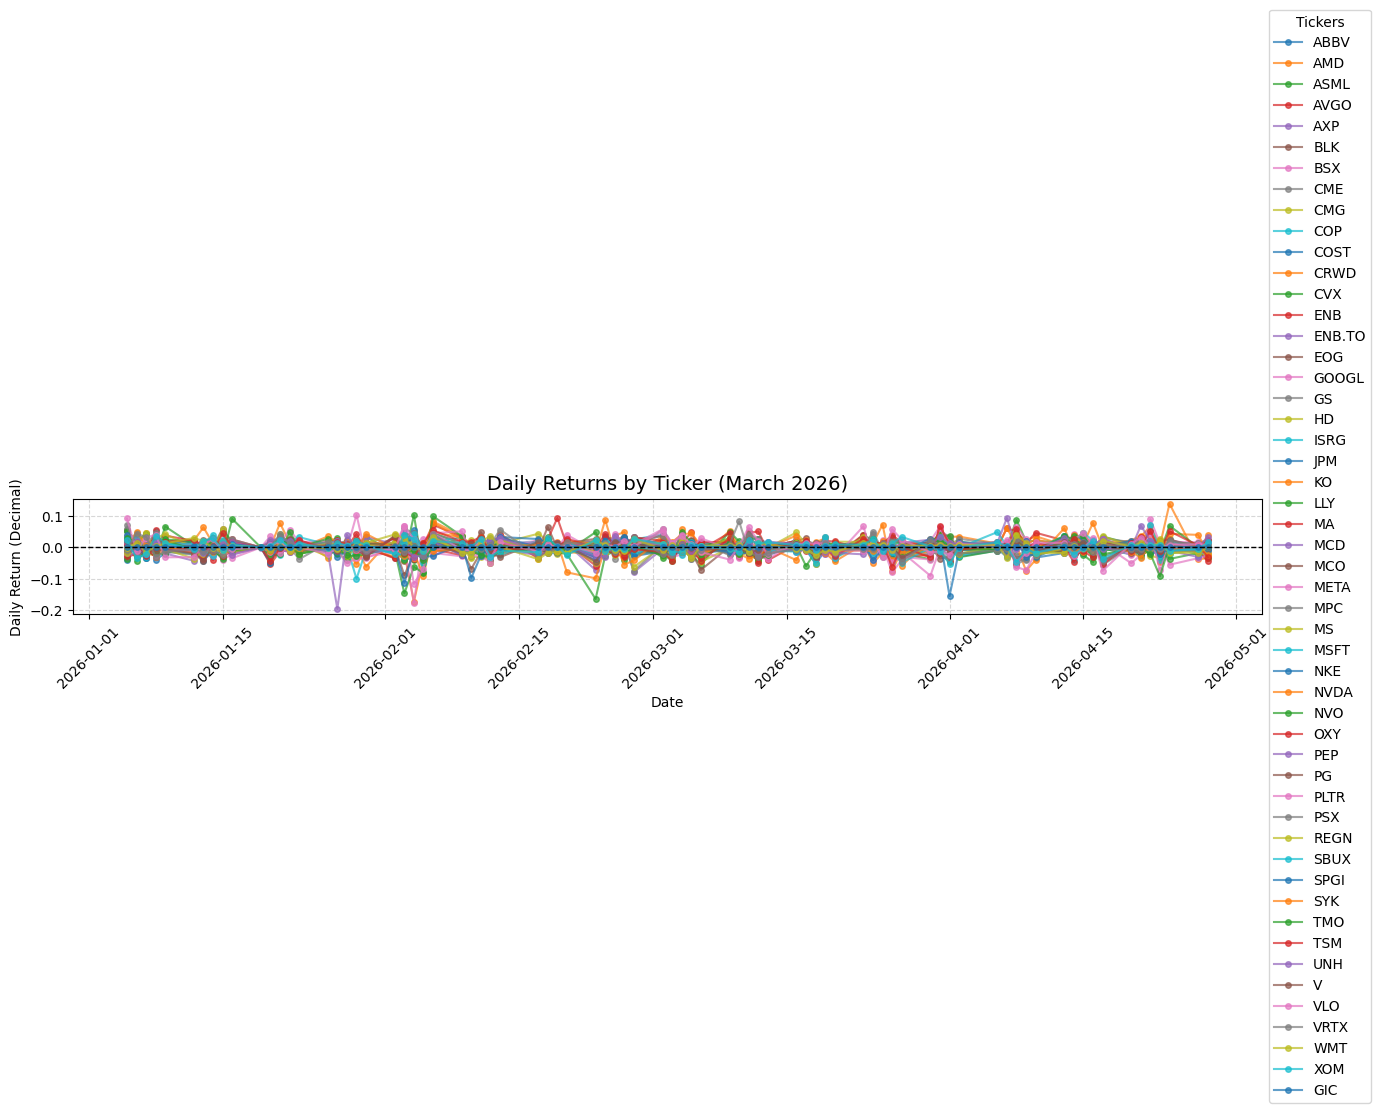

In [ ]:
import matplotlib.pyplot as plt

# 1. Plotting the daily returns from returns_df
plt.figure(figsize=(14, 7))
for ticker in returns_df.columns:
    plt.plot(returns_df.index, returns_df[ticker], label=ticker, marker='o', markersize=4, alpha=0.7)

plt.title("Daily Returns by Ticker (March 2026)", fontsize=14)
plt.ylabel("Daily Return (Decimal)")
plt.xlabel("Date")
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Tickers")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Daily Returns Visualization


Solid: '-'

Dashed: '--'

Dotted: ':'

Dash-Dot: '-.'

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

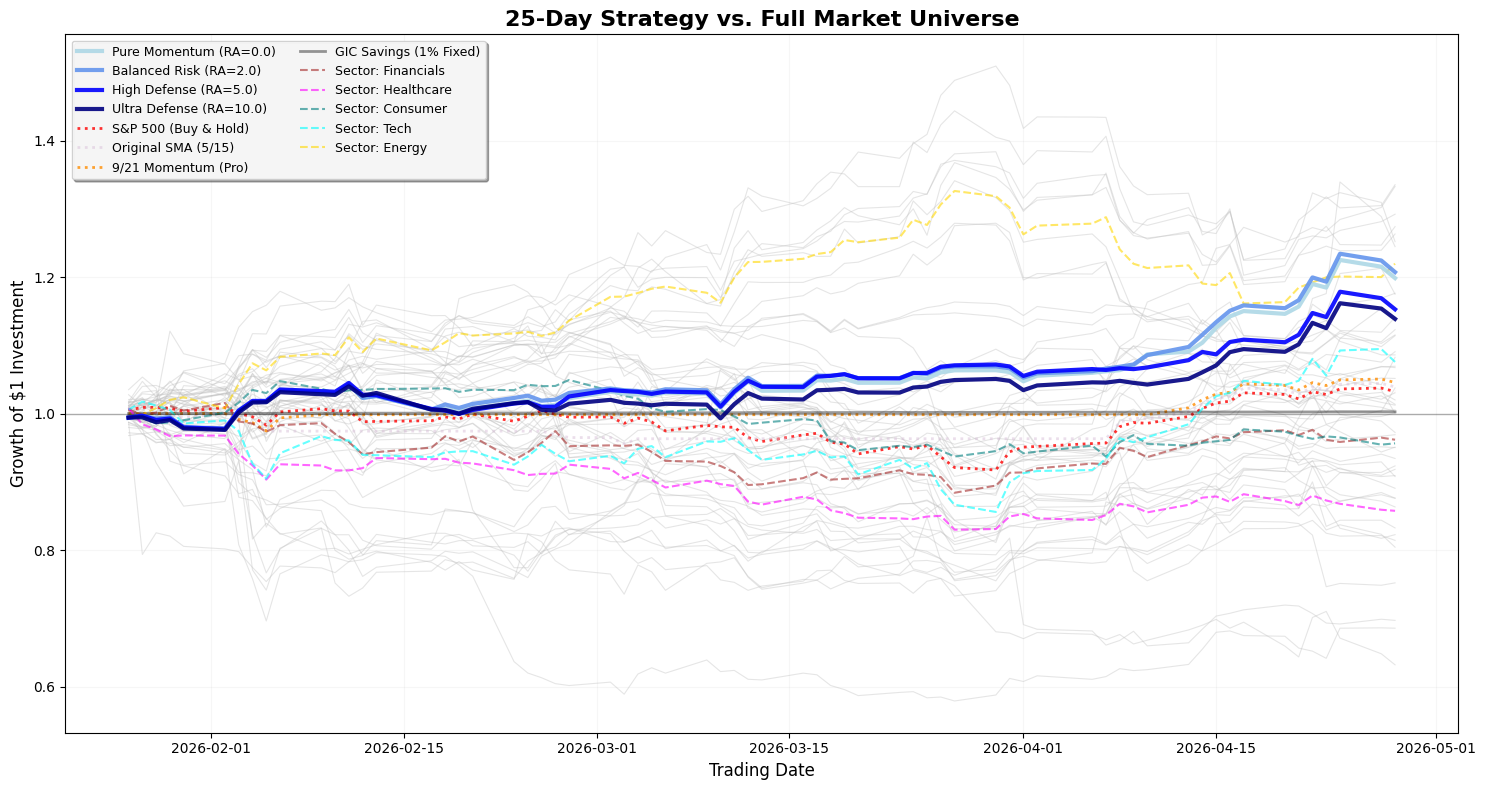


           FINAL PERFORMANCE SUMMARY
Pure Momentum (RA=0.0)        :   19.85%
Balanced Risk (RA=2.0)        :   20.72%
High Defense (RA=5.0)         :   15.28%
Ultra Defense (RA=10.0)       :   13.87%

--- Market & Momentum Baselines ---
S&P 500 (Market)              :    3.23%
GIC Savings (1% Fixed)        :    0.26%
Original SMA (5/15)           :    3.91%
9/21 Momentum (Wanik Ref)     :    4.55%

--- Industry Baselines ---
Industry - Energy                  :   21.97%
Industry - Tech                    :    7.57%
Industry - Financials              :   -3.83%
Industry - Consumer                :   -4.36%
Industry - Healthcare              :  -14.25%


In [ ]:
plt.figure(figsize=(15, 8))

# 1. Styles for your Models (Solid Tonal Blue)
colors = {0.0: '#add8e6', 2.0: '#6495ed', 5.0: '#0000ff', 10.0: '#000080'}
labels = {0.0: 'Pure Momentum (RA=0.0)', 2.0: 'Balanced Risk (RA=2.0)',
          5.0: 'High Defense (RA=5.0)', 10.0: 'Ultra Defense (RA=10.0)'}

final_returns_dict = {}
display_df = None

# 2. Process and Plot Each Risk Level Strategy
for ra in risk_levels:
    if ra in multi_allocations and multi_allocations[ra]:
        display_df = pd.DataFrame(multi_allocations[ra]).T.fillna(0)
        strat_returns = (returns_df.loc[display_df.index] * display_df).sum(axis=1)
        cum_strat = (1 + strat_returns).cumprod()
        final_returns_dict[ra] = (cum_strat.iloc[-1] - 1) * 100
        # SOLID lines for primary results
        plt.plot(cum_strat, alpha=0.9, label=labels[ra], linewidth=3, color=colors[ra], linestyle='-', zorder=10)

if display_df is not None:
    # 3. Market Baselines
    benchmark_pct = benchmark_data.pct_change().dropna()
    aligned_benchmark = benchmark_pct.reindex(display_df.index).fillna(0)
    cum_benchmark = (1 + aligned_benchmark).cumprod()

    # SMA & 9/21 Pro Momentum
    sma_fast, sma_slow = benchmark_data.rolling(5).mean(), benchmark_data.rolling(15).mean()
    sma_signals = (sma_fast > sma_slow).astype(int).shift(1).fillna(0)
    cum_sma = (1 + (benchmark_pct * sma_signals).reindex(display_df.index).fillna(0)).cumprod()

    pro_fast, pro_slow = benchmark_data.rolling(9).mean(), benchmark_data.rolling(21).mean()
    pro_signals = (pro_fast > pro_slow).astype(int).shift(1).fillna(0)
    cum_pro_mom = (1 + (benchmark_pct * pro_signals).reindex(display_df.index).fillna(0)).cumprod()

    # GIC Baseline (1% Annual)
    gic_series = pd.Series(gic_daily_return, index=display_df.index)
    cum_gic = (1 + gic_series).cumprod()

    # Plot Benchmarks (Dotted :)
    plt.plot(cum_benchmark, alpha=0.8, label='S&P 500 (Buy & Hold)', color='red', linestyle=':', linewidth=2)
    plt.plot(cum_sma, alpha=0.5, label='Original SMA (5/15)', color='thistle', linestyle=':', linewidth=2)
    plt.plot(cum_pro_mom, alpha=0.8, label='9/21 Momentum (Pro)', color='darkorange', linestyle=':', linewidth=2)
    plt.plot(cum_gic, label='GIC Savings (1% Fixed)', color='black', linewidth=2, linestyle='-', alpha=0.4)

    # 4. Industry Performance (Dashed --)
    sector_colors = {'Tech': 'cyan', 'Energy': 'gold', 'Healthcare': 'magenta', 'Financials': 'brown', 'Consumer': 'teal', 'Cash': 'grey'}
    sector_final_returns = {}
    for sector in unique_sectors:
        sector_tickers = [t for t in returns_df.columns if sector_map.get(t) == sector and t != 'GIC']
        if sector_tickers:
            sector_daily = returns_df[sector_tickers].mean(axis=1).reindex(display_df.index).fillna(0)
            cum_sector = (1 + sector_daily).cumprod()
            sector_final_returns[sector] = (float(cum_sector.iloc[-1]) - 1) * 100
            plt.plot(cum_sector, alpha=0.6, label=f'Sector: {sector}', linewidth=1.5, color=sector_colors.get(sector, 'grey'), linestyle='--')

    # 5. INDIVIDUAL COMPANY LINES (Deepened visibility)
    asset_cum_returns = (1 + returns_df.loc[display_df.index]).cumprod()
    for ticker in asset_cum_returns.columns:
        if ticker != 'GIC':
            plt.plot(asset_cum_returns[ticker], alpha=0.4, linewidth=0.8, color='silver', zorder=1)

    # Formatting
    plt.title("25-Day Strategy vs. Full Market Universe", fontsize=16, fontweight='bold')
    plt.ylabel("Growth of $1 Investment", fontsize=12)
    plt.xlabel("Trading Date", fontsize=12)

    # --- UPDATED UNIFIED LEGEND ---
    # Moved inside to the top-left, split into 2 columns, with a solid white background
    plt.legend(loc='upper left', fontsize=9, frameon=True, ncol=2, facecolor='white', framealpha=0.9, shadow=True)

    plt.grid(True, which='both', linestyle='-', alpha=0.1)
    plt.axhline(y=1.0, color='black', linewidth=1, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 7. Final Scorecard (RESTORED INDUSTRIES)
    print("\n" + "="*45)
    print("           FINAL PERFORMANCE SUMMARY")
    print("="*45)
    for ra in sorted(final_returns_dict.keys()):
        print(f"{labels[ra]:<30}: {final_returns_dict[ra]:>7.2f}%")

    print("\n--- Market & Momentum Baselines ---")
    print(f"{'S&P 500 (Market)':<30}: {(cum_benchmark.iloc[-1]-1).item()*100:>7.2f}%")
    print(f"{'GIC Savings (1% Fixed)':<30}: {(cum_gic.iloc[-1]-1).item()*100:>7.2f}%")
    print(f"{'Original SMA (5/15)':<30}: {(cum_sma.iloc[-1]-1).item()*100:>7.2f}%")
    print(f"{'9/21 Momentum (Wanik Ref)':<30}: {(cum_pro_mom.iloc[-1]-1).item()*100:>7.2f}%")

    print("\n--- Industry Baselines ---")
    for sector, ret in sorted(sector_final_returns.items(), key=lambda x: x[1], reverse=True):
        print(f"Industry - {sector:<24}: {ret:>7.2f}%")

#

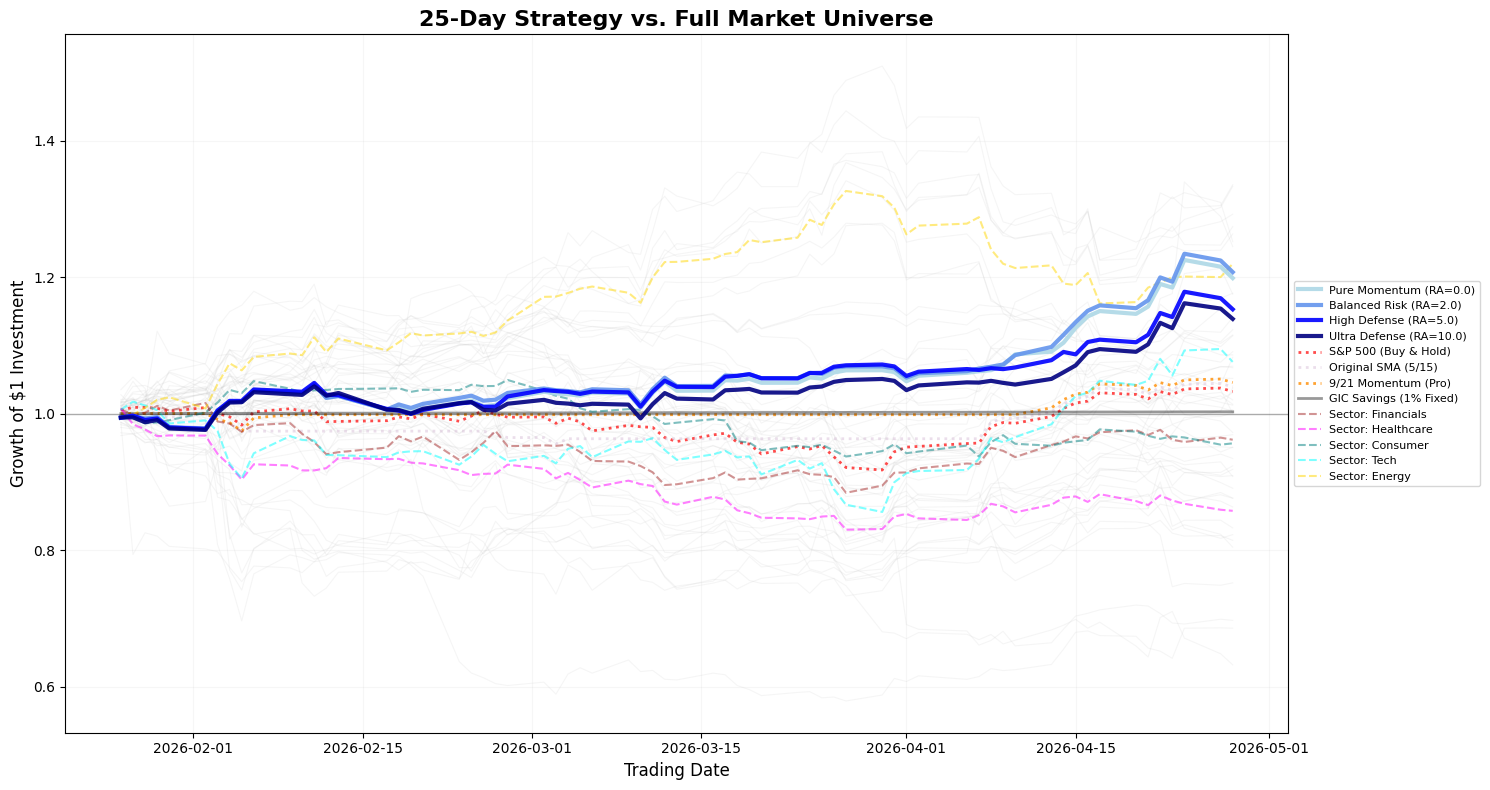


           FINAL PERFORMANCE SUMMARY
Pure Momentum (RA=0.0)        :   19.85%
Balanced Risk (RA=2.0)        :   20.72%
High Defense (RA=5.0)         :   15.28%
Ultra Defense (RA=10.0)       :   13.87%

--- Market & Momentum Baselines ---
S&P 500 (Market)              :    3.23%
GIC Savings (1% Fixed)        :    0.26%
Original SMA (5/15)           :    3.91%
9/21 Momentum (Wanik Ref)     :    4.55%

--- Industry Baselines ---
Industry - Energy                  :   21.97%
Industry - Tech                    :    7.57%
Industry - Financials              :   -3.83%
Industry - Consumer                :   -4.36%
Industry - Healthcare              :  -14.25%


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(15, 8))

# 1. Styles for your Models (Solid Tonal Blue)
colors = {0.0: '#add8e6', 2.0: '#6495ed', 5.0: '#0000ff', 10.0: '#000080'}
labels = {0.0: 'Pure Momentum (RA=0.0)', 2.0: 'Balanced Risk (RA=2.0)',
          5.0: 'High Defense (RA=5.0)', 10.0: 'Ultra Defense (RA=10.0)'}

final_returns_dict = {}
display_df = None

# 2. Process and Plot Each Risk Level Strategy
for ra in risk_levels:
    if ra in multi_allocations and multi_allocations[ra]:
        display_df = pd.DataFrame(multi_allocations[ra]).T.fillna(0)
        strat_returns = (returns_df.loc[display_df.index] * display_df).sum(axis=1)
        cum_strat = (1 + strat_returns).cumprod()
        final_returns_dict[ra] = (cum_strat.iloc[-1] - 1) * 100
        # SOLID lines for primary results
        plt.plot(cum_strat, alpha=0.9, label=labels[ra], linewidth=3, color=colors[ra], linestyle='-', zorder=10)

if display_df is not None:
    # 3. Market Baselines
    benchmark_pct = benchmark_data.pct_change().dropna()
    aligned_benchmark = benchmark_pct.reindex(display_df.index).fillna(0)
    cum_benchmark = (1 + aligned_benchmark).cumprod()

    # SMA & 9/21 Pro Momentum
    sma_fast, sma_slow = benchmark_data.rolling(5).mean(), benchmark_data.rolling(15).mean()
    sma_signals = (sma_fast > sma_slow).astype(int).shift(1).fillna(0)
    cum_sma = (1 + (benchmark_pct * sma_signals).reindex(display_df.index).fillna(0)).cumprod()

    pro_fast, pro_slow = benchmark_data.rolling(9).mean(), benchmark_data.rolling(21).mean()
    pro_signals = (pro_fast > pro_slow).astype(int).shift(1).fillna(0)
    cum_pro_mom = (1 + (benchmark_pct * pro_signals).reindex(display_df.index).fillna(0)).cumprod()

    # GIC Baseline (1% Annual)
    gic_series = pd.Series(gic_daily_return, index=display_df.index)
    cum_gic = (1 + gic_series).cumprod()

    # Plot Benchmarks (Dotted :)
    plt.plot(cum_benchmark, alpha=0.7, label='S&P 500 (Buy & Hold)', color='red', linestyle=':', linewidth=2)
    plt.plot(cum_sma, alpha=0.5, label='Original SMA (5/15)', color='thistle', linestyle=':', linewidth=2)
    plt.plot(cum_pro_mom, alpha=0.8, label='9/21 Momentum (Pro)', color='darkorange', linestyle=':', linewidth=2)
    plt.plot(cum_gic, label='GIC Savings (1% Fixed)', color='black', linewidth=2, linestyle='-', alpha=0.4)

    # 4. Industry Performance (Dashed --)
    sector_colors = {'Tech': 'cyan', 'Energy': 'gold', 'Healthcare': 'magenta', 'Financials': 'brown', 'Consumer': 'teal', 'Cash': 'grey'}
    sector_final_returns = {}
    for sector in unique_sectors:
        sector_tickers = [t for t in returns_df.columns if sector_map.get(t) == sector and t != 'GIC']
        if sector_tickers:
            sector_daily = returns_df[sector_tickers].mean(axis=1).reindex(display_df.index).fillna(0)
            cum_sector = (1 + sector_daily).cumprod()
            sector_final_returns[sector] = (float(cum_sector.iloc[-1]) - 1) * 100
            plt.plot(cum_sector, alpha=0.5, label=f'Sector: {sector}', linewidth=1.5, color=sector_colors.get(sector, 'grey'), linestyle='--')

    # 5. INDIVIDUAL COMPANY LINES (Deepened visibility)
    asset_cum_returns = (1 + returns_df.loc[display_df.index]).cumprod()
    for ticker in asset_cum_returns.columns:
        if ticker != 'GIC':
            plt.plot(asset_cum_returns[ticker], alpha=0.15, linewidth=0.8, color='silver', zorder=1)

    # Formatting
    plt.title("25-Day Strategy vs. Full Market Universe", fontsize=16, fontweight='bold')
    plt.ylabel("Growth of $1 Investment", fontsize=12)
    plt.xlabel("Trading Date", fontsize=12)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8, frameon=True)
    plt.grid(True, which='both', linestyle='-', alpha=0.1)
    plt.axhline(y=1.0, color='black', linewidth=1, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 7. Final Scorecard (RESTORED INDUSTRIES)
    print("\n" + "="*45)
    print("           FINAL PERFORMANCE SUMMARY")
    print("="*45)
    for ra in sorted(final_returns_dict.keys()):
        print(f"{labels[ra]:<30}: {final_returns_dict[ra]:>7.2f}%")

    print("\n--- Market & Momentum Baselines ---")
    print(f"{'S&P 500 (Market)':<30}: {(cum_benchmark.iloc[-1]-1).item()*100:>7.2f}%")
    print(f"{'GIC Savings (1% Fixed)':<30}: {(cum_gic.iloc[-1]-1).item()*100:>7.2f}%")
    print(f"{'Original SMA (5/15)':<30}: {(cum_sma.iloc[-1]-1).item()*100:>7.2f}%")
    print(f"{'9/21 Momentum (Wanik Ref)':<30}: {(cum_pro_mom.iloc[-1]-1).item()*100:>7.2f}%")

    print("\n--- Industry Baselines ---")
    for sector, ret in sorted(sector_final_returns.items(), key=lambda x: x[1], reverse=True):
        print(f"Industry - {sector:<24}: {ret:>7.2f}%")